# Day 11 -- Pandas Series: Complete Guide
### 90-Day Gen AI Engineer Roadmap

---
**Author:** Shaurab Kumar Jha  
**Date:** Day 11 of 90  
**Goal:** MNC-ready Python & Gen AI Engineer

## Topics Covered

| Section | Topic |
|---------|-------|
| 1  | Pandas kya hai -- overview and why it matters for Gen AI |
| 2  | Series banana -- list, dict, scalar, numpy array, custom index |
| 3  | Series attributes -- size, dtype, name, is_unique, index, values |
| 4  | Viewing methods -- head, tail, sample, value_counts |
| 5  | Sorting -- sort_values, sort_index |
| 6  | Math and statistics -- count, sum, mean, median, mode, std, var, min, max, describe |
| 7  | Indexing -- integer, negative, slicing, fancy, label-based |
| 8  | Operations -- arithmetic, relational, boolean indexing |
| 9  | Important methods -- astype, between, clip, drop_duplicates, isnull, dropna, fillna, isin, apply, copy |
| 10 | Plotting with Series |
| 11 | Capstone -- Cricket player score analysis |

---

**Why Pandas matters for Gen AI:**
- Every real dataset comes as a CSV or DataFrame
- Feature engineering happens in Pandas before data goes into a model
- EDA (exploratory data analysis) is Pandas
- LLM fine-tuning datasets are read, cleaned, and shaped with Pandas
- RAG document metadata is stored and queried using DataFrame operations

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Pandas version:  {pd.__version__}")
print(f"NumPy version:   {np.__version__}")

Pandas version:  2.2.3
NumPy version:   2.3.3


---
# SECTION 1 -- Pandas kya hai?

Pandas ek Python library hai jo tabular data ke saath kaam karne ke liye bani hai.

**Two main data structures:**
- **Series** -- 1D labeled array (ek column)
- **DataFrame** -- 2D labeled table (multiple columns)

**Series vs NumPy array ka fark:**

| Feature | NumPy Array | Pandas Series |
|---------|-------------|---------------|
| Index | Integer only (0,1,2...) | Any type (int, str, date) |
| Data types | Homogeneous (ek hi type) | Homogeneous per Series |
| Missing values | No native support | NaN handled natively |
| Labels | No | Yes -- named index |
| Operations | Fast vectorized math | Same + label-aware ops |

---
# SECTION 2 -- Series Banana (Creating a Series)

6 tarike hain ek Series banane ke.

In [2]:
# --------------------------------------------------
# METHOD 1: Python list se
# --------------------------------------------------

s_list = pd.Series([10, 20, 30, 40, 50])
print("From Python list:")
print(s_list)
print(f"type: {type(s_list)}")

From Python list:
0    10
1    20
2    30
3    40
4    50
dtype: int64
type: <class 'pandas.core.series.Series'>


In [3]:
# --------------------------------------------------
# METHOD 2: List + custom index
# --------------------------------------------------

s_custom = pd.Series(
    [85, 92, 78, 96, 88],
    index=["Math", "Science", "English", "History", "CS"],
    name="Rahul_Marks"
)
print("Custom string index + name:")
print(s_custom)

Custom string index + name:
Math       85
Science    92
English    78
History    96
CS         88
Name: Rahul_Marks, dtype: int64


In [4]:
# --------------------------------------------------
# METHOD 3: Python dict se
# Keys become index, values become data
# --------------------------------------------------

scores_dict = {
    "Rohit":  68,
    "Virat":  82,
    "Dhoni":  45,
    "Kohli":  91,
    "Bumrah": 12
}
s_dict = pd.Series(scores_dict, name="IPL_Scores")
print("From dict (keys = index):")
print(s_dict)

From dict (keys = index):
Rohit     68
Virat     82
Dhoni     45
Kohli     91
Bumrah    12
Name: IPL_Scores, dtype: int64


In [5]:
# --------------------------------------------------
# METHOD 4: NumPy array se
# --------------------------------------------------

arr = np.array([1.1, 2.2, 3.3, 4.4, 5.5])
s_np = pd.Series(arr, name="From_NumPy")
print("From NumPy array:")
print(s_np)

From NumPy array:
0    1.1
1    2.2
2    3.3
3    4.4
4    5.5
Name: From_NumPy, dtype: float64


In [6]:
# --------------------------------------------------
# METHOD 5: Scalar se (ek value, multiple index)
# --------------------------------------------------

s_scalar = pd.Series(99, index=["a", "b", "c", "d"], name="Scalar_Fill")
print("From scalar (broadcast to all indices):")
print(s_scalar)

From scalar (broadcast to all indices):
a    99
b    99
c    99
d    99
Name: Scalar_Fill, dtype: int64


In [7]:
# --------------------------------------------------
# METHOD 6: With dtype explicitly set
# --------------------------------------------------

s_f32 = pd.Series([1, 2, 3, 4, 5], dtype=np.float32, name="float32_series")
s_str = pd.Series(["python", "pandas", "numpy"], dtype="string", name="tech_stack")
s_bool = pd.Series([True, False, True, True, False], dtype=bool, name="flags")
s_cat = pd.Series(["low", "high", "medium", "low", "high"], dtype="category", name="priority")

print("float32 dtype:")
print(s_f32)
print(f"\nstring dtype: {s_str.tolist()}  dtype={s_str.dtype}")
print(f"bool dtype:   {s_bool.tolist()}  dtype={s_bool.dtype}")
print(f"\ncategory dtype:")
print(s_cat)
print(f"Categories: {s_cat.cat.categories.tolist()}")

float32 dtype:
0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
Name: float32_series, dtype: float32

string dtype: ['python', 'pandas', 'numpy']  dtype=string
bool dtype:   [True, False, True, True, False]  dtype=bool

category dtype:
0       low
1      high
2    medium
3       low
4      high
Name: priority, dtype: category
Categories (3, object): ['high', 'low', 'medium']
Categories: ['high', 'low', 'medium']


---
# SECTION 3 -- Series Attributes

In [8]:
# Working Series for all attribute demos
s = pd.Series(
    [45, 82, 67, 91, 55, 78, 91, 41, 88, 62, np.nan],
    index=[f"Match_{i+1}" for i in range(11)],
    name="Scores"
)
print("Working Series:")
print(s)

Working Series:
Match_1     45.0
Match_2     82.0
Match_3     67.0
Match_4     91.0
Match_5     55.0
Match_6     78.0
Match_7     91.0
Match_8     41.0
Match_9     88.0
Match_10    62.0
Match_11     NaN
Name: Scores, dtype: float64


In [9]:
# --------------------------------------------------
# ALL ATTRIBUTES
# --------------------------------------------------

print("=" * 45)
print("Series Attributes")
print("=" * 45)

print(f"s.name       : {s.name}")
print(f"s.dtype      : {s.dtype}")
print(f"s.size       : {s.size}         (total elements including NaN)")
print(f"s.shape      : {s.shape}        (tuple -- Series is always 1D)")
print(f"s.ndim       : {s.ndim}            (always 1 for Series)")
print(f"s.nbytes     : {s.nbytes}          (memory in bytes)")
print(f"s.is_unique  : {s.is_unique}   (False because 91 appears twice)")
print(f"s.hasnans    : {s.hasnans}     (True because NaN is present)")
print(f"s.empty      : {s.empty}")

print(f"\ns.index:")
print(f"  {s.index.tolist()}")
print(f"  type: {type(s.index).__name__}")

print(f"\ns.values:")
print(f"  {s.values}")
print(f"  type: {type(s.values).__name__}")

print(f"\ns.array (pandas ExtensionArray):")
print(f"  type: {type(s.array).__name__}")

# Rename series
s_renamed = s.rename("Player_Scores")
print(f"\ns.rename('Player_Scores').name: {s_renamed.name}")

# Rename index
s_idx_named = s.copy()
s_idx_named.index.name = "Match"
print(f"s.index.name = 'Match':")
print(s_idx_named.head(3))

Series Attributes
s.name       : Scores
s.dtype      : float64
s.size       : 11         (total elements including NaN)
s.shape      : (11,)        (tuple -- Series is always 1D)
s.ndim       : 1            (always 1 for Series)
s.nbytes     : 88          (memory in bytes)
s.is_unique  : False   (False because 91 appears twice)
s.hasnans    : True     (True because NaN is present)
s.empty      : False

s.index:
  ['Match_1', 'Match_2', 'Match_3', 'Match_4', 'Match_5', 'Match_6', 'Match_7', 'Match_8', 'Match_9', 'Match_10', 'Match_11']
  type: Index

s.values:
  [45. 82. 67. 91. 55. 78. 91. 41. 88. 62. nan]
  type: ndarray

s.array (pandas ExtensionArray):
  type: NumpyExtensionArray

s.rename('Player_Scores').name: Player_Scores
s.index.name = 'Match':
Match
Match_1    45.0
Match_2    82.0
Match_3    67.0
Name: Scores, dtype: float64


---
# SECTION 4 -- Viewing Methods: head, tail, sample, value_counts

In [10]:
# Working Series -- player scores over 20 matches
np.random.seed(42)
scores_raw = np.random.choice(
    [0, 0, 5, 12, 23, 34, 45, 56, 67, 78, 82, 91, 100, 112, 134],
    size=20
)
player = pd.Series(
    scores_raw,
    index=[f"M{i:02d}" for i in range(1, 21)],
    name="Virat_Kohli_Scores"
)
print("Full Series (20 matches):")
print(player)

Full Series (20 matches):
M01     45
M02     12
M03    100
M04    134
M05     82
M06     56
M07    100
M08     23
M09     45
M10     78
M11      5
M12     45
M13     82
M14     82
M15     56
M16     23
M17     12
M18     56
M19     56
M20      5
Name: Virat_Kohli_Scores, dtype: int64


In [11]:
# head and tail
print("head(5) -- first 5:")
print(player.head(5))

print("\ntail(5) -- last 5:")
print(player.tail(5))

print("\ntail(3):")
print(player.tail(3))

head(5) -- first 5:
M01     45
M02     12
M03    100
M04    134
M05     82
Name: Virat_Kohli_Scores, dtype: int64

tail(5) -- last 5:
M16    23
M17    12
M18    56
M19    56
M20     5
Name: Virat_Kohli_Scores, dtype: int64

tail(3):
M18    56
M19    56
M20     5
Name: Virat_Kohli_Scores, dtype: int64


In [12]:
# sample -- random rows
print("sample(5) -- 5 random rows:")
print(player.sample(5, random_state=0))

print("\nsample(frac=0.3) -- 30% of data:")
print(player.sample(frac=0.3, random_state=1))

print("\nsample(5, weights=...) -- weighted sampling:")
# Higher scores more likely to be sampled
weights = player + 1   # avoid zero weight
print(player.sample(5, weights=weights, random_state=2))

sample(5) -- 5 random rows:
M19    56
M02    12
M20     5
M09    45
M11     5
Name: Virat_Kohli_Scores, dtype: int64

sample(frac=0.3) -- 30% of data:
M04    134
M17     12
M07    100
M11      5
M03    100
M15     56
Name: Virat_Kohli_Scores, dtype: int64

sample(5, weights=...) -- weighted sampling:
M07    100
M01     45
M10     78
M05     82
M04    134
Name: Virat_Kohli_Scores, dtype: int64


In [13]:
# value_counts -- frequency of each unique value
s_grades = pd.Series(
    ["A", "B", "A", "C", "B", "A", "D", "B", "A", "C", "A", "B", "F"],
    name="Grades"
)

print("value_counts() -- absolute frequency:")
print(s_grades.value_counts())

print("\nvalue_counts(normalize=True) -- relative frequency (proportions):")
print(s_grades.value_counts(normalize=True).round(3))

print("\nvalue_counts(ascending=True) -- least common first:")
print(s_grades.value_counts(ascending=True))

print("\nvalue_counts(dropna=False) -- include NaN count:")
s_with_nan = pd.Series(["A", "B", np.nan, "A", np.nan, "C"])
print(s_with_nan.value_counts(dropna=False))

# value_counts on numeric -- bins
print("\nvalue_counts(bins=4) on numeric -- histogram-style:")
print(player.value_counts(bins=4, sort=False))

value_counts() -- absolute frequency:
Grades
A    5
B    4
C    2
D    1
F    1
Name: count, dtype: int64

value_counts(normalize=True) -- relative frequency (proportions):
Grades
A    0.385
B    0.308
C    0.154
D    0.077
F    0.077
Name: proportion, dtype: float64

value_counts(ascending=True) -- least common first:
Grades
D    1
F    1
C    2
B    4
A    5
Name: count, dtype: int64

value_counts(dropna=False) -- include NaN count:
A      2
NaN    2
B      1
C      1
Name: count, dtype: int64

value_counts(bins=4) on numeric -- histogram-style:
(4.87, 37.25]      6
(37.25, 69.5]      7
(69.5, 101.75]     6
(101.75, 134.0]    1
Name: count, dtype: int64


---
# SECTION 5 -- Sorting

In [14]:
s = pd.Series(
    [45, 12, 89, 34, 67, np.nan, 23, 78],
    index=["e", "b", "h", "a", "f", "c", "g", "d"],
    name="values"
)
print("Original:")
print(s)

# sort_values -- sort by data values
print("\nsort_values() -- ascending (default):")
print(s.sort_values())

print("\nsort_values(ascending=False) -- descending:")
print(s.sort_values(ascending=False))

print("\nsort_values(na_position='first') -- NaN at start:")
print(s.sort_values(na_position='first'))

# sort_index -- sort by index labels
print("\nsort_index() -- alphabetical index:")
print(s.sort_index())

print("\nsort_index(ascending=False):")
print(s.sort_index(ascending=False))

# inplace parameter
s_copy = s.copy()
s_copy.sort_values(inplace=True)
print("\nAfter sort_values(inplace=True):")
print(s_copy)
print("  (Note: inplace=True modifies the original, returns None)")

# nlargest and nsmallest -- top/bottom N values
print("\nnlargest(3) -- top 3 values:")
print(s.nlargest(3))

print("\nnsmallest(3) -- bottom 3 values:")
print(s.nsmallest(3))

Original:
e    45.0
b    12.0
h    89.0
a    34.0
f    67.0
c     NaN
g    23.0
d    78.0
Name: values, dtype: float64

sort_values() -- ascending (default):
b    12.0
g    23.0
a    34.0
e    45.0
f    67.0
d    78.0
h    89.0
c     NaN
Name: values, dtype: float64

sort_values(ascending=False) -- descending:
h    89.0
d    78.0
f    67.0
e    45.0
a    34.0
g    23.0
b    12.0
c     NaN
Name: values, dtype: float64

sort_values(na_position='first') -- NaN at start:
c     NaN
b    12.0
g    23.0
a    34.0
e    45.0
f    67.0
d    78.0
h    89.0
Name: values, dtype: float64

sort_index() -- alphabetical index:
a    34.0
b    12.0
c     NaN
d    78.0
e    45.0
f    67.0
g    23.0
h    89.0
Name: values, dtype: float64

sort_index(ascending=False):
h    89.0
g    23.0
f    67.0
e    45.0
d    78.0
c     NaN
b    12.0
a    34.0
Name: values, dtype: float64

After sort_values(inplace=True):
b    12.0
g    23.0
a    34.0
e    45.0
f    67.0
d    78.0
h    89.0
c     NaN
Name: values, dtype:

---
# SECTION 6 -- Math and Statistics

In [15]:
scores = pd.Series(
    [72, 85, 91, 63, 78, 90, 55, 88, 76, 82, 69, 95, 74, 83, 61],
    name="Exam_Scores"
)

print("=" * 50)
print("Statistics Methods")
print("=" * 50)
print(f"  count()         : {scores.count()}     (non-NaN count)")
print(f"  sum()           : {scores.sum()}")
print(f"  mean()          : {scores.mean():.4f}")
print(f"  median()        : {scores.median():.4f}")
print(f"  mode()          : {scores.mode().tolist()}")
print(f"  std()           : {scores.std():.4f}   (sample std, ddof=1)")
print(f"  std(ddof=0)     : {scores.std(ddof=0):.4f}   (population std)")
print(f"  var()           : {scores.var():.4f}")
print(f"  min()           : {scores.min()}")
print(f"  max()           : {scores.max()}")
print(f"  idxmin()        : {scores.idxmin()}    (index of min value)")
print(f"  idxmax()        : {scores.idxmax()}    (index of max value)")
print(f"  nunique()       : {scores.nunique()}    (number of unique values)")
print(f"  quantile(0.25)  : {scores.quantile(0.25)}   (Q1)")
print(f"  quantile(0.75)  : {scores.quantile(0.75)}   (Q3)")
print(f"  skew()          : {scores.skew():.4f}  (skewness -- negative = left skewed)")
print(f"  kurt()          : {scores.kurt():.4f}  (kurtosis -- tail heaviness)")
print(f"  sem()           : {scores.sem():.4f}   (standard error of mean)")
print(f"  mad()           : {scores.mad():.4f}   (mean absolute deviation)")
print(f"  abs().max()     : {scores.abs().max()}     (max absolute value)")

# describe -- full statistical summary
print("\ndescribe() -- full summary:")
print(scores.describe())

# Custom percentiles in describe
print("\ndescribe(percentiles=[0.1, 0.5, 0.9]):")
print(scores.describe(percentiles=[0.1, 0.5, 0.9]))

Statistics Methods
  count()         : 15     (non-NaN count)
  sum()           : 1162
  mean()          : 77.4667
  median()        : 78.0000
  mode()          : [55, 61, 63, 69, 72, 74, 76, 78, 82, 83, 85, 88, 90, 91, 95]
  std()           : 11.8555   (sample std, ddof=1)
  std(ddof=0)     : 11.4535   (population std)
  var()           : 140.5524
  min()           : 55
  max()           : 95
  idxmin()        : 6    (index of min value)
  idxmax()        : 11    (index of max value)
  nunique()       : 15    (number of unique values)
  quantile(0.25)  : 70.5   (Q1)
  quantile(0.75)  : 86.5   (Q3)
  skew()          : -0.3933  (skewness -- negative = left skewed)
  kurt()          : -0.7215  (kurtosis -- tail heaviness)
  sem()           : 3.0611   (standard error of mean)


AttributeError: 'Series' object has no attribute 'mad'

In [16]:
# Cumulative methods
s_small = pd.Series([3, 1, 4, 1, 5, 9, 2, 6], name="values")
print("Series:", s_small.tolist())

print("\nCumulative methods:")
print(f"  cumsum():  {s_small.cumsum().tolist()}")
print(f"  cumprod(): {s_small.cumprod().tolist()}")
print(f"  cummax():  {s_small.cummax().tolist()}  (running max)")
print(f"  cummin():  {s_small.cummin().tolist()}  (running min)")

# diff and pct_change
prices = pd.Series([100, 105, 103, 108, 112, 109, 115], name="Stock_Price")
print(f"\nStock prices: {prices.tolist()}")
print(f"  diff(1):       {prices.diff(1).tolist()}       (daily change)")
print(f"  pct_change():  {[round(x,3) for x in prices.pct_change().tolist()]}  (daily % change)")

# rank
s_rank = pd.Series([30, 10, 50, 10, 40], name="values")
print(f"\nRanking: {s_rank.tolist()}")
print(f"  rank():              {s_rank.rank().tolist()}    (average for ties)")
print(f"  rank(method='min'):  {s_rank.rank(method='min').tolist()}  (min rank for ties)")
print(f"  rank(method='max'):  {s_rank.rank(method='max').tolist()}  (max rank for ties)")
print(f"  rank(ascending=F):   {s_rank.rank(ascending=False).tolist()}  (reverse rank)")

Series: [3, 1, 4, 1, 5, 9, 2, 6]

Cumulative methods:
  cumsum():  [3, 4, 8, 9, 14, 23, 25, 31]
  cumprod(): [3, 3, 12, 12, 60, 540, 1080, 6480]
  cummax():  [3, 3, 4, 4, 5, 9, 9, 9]  (running max)
  cummin():  [3, 1, 1, 1, 1, 1, 1, 1]  (running min)

Stock prices: [100, 105, 103, 108, 112, 109, 115]
  diff(1):       [nan, 5.0, -2.0, 5.0, 4.0, -3.0, 6.0]       (daily change)
  pct_change():  [nan, 0.05, -0.019, 0.049, 0.037, -0.027, 0.055]  (daily % change)

Ranking: [30, 10, 50, 10, 40]
  rank():              [3.0, 1.5, 5.0, 1.5, 4.0]    (average for ties)
  rank(method='min'):  [3.0, 1.0, 5.0, 1.0, 4.0]  (min rank for ties)
  rank(method='max'):  [3.0, 2.0, 5.0, 2.0, 4.0]  (max rank for ties)
  rank(ascending=F):   [3.0, 4.5, 1.0, 4.5, 2.0]  (reverse rank)


---
# SECTION 7 -- Indexing

Series mein 4 types of indexing hote hain:
1. **Integer-based** -- position number (like list)
2. **Label-based** -- index label
3. **Slicing** -- ranges
4. **Fancy indexing** -- list of indices

In [17]:
# Two types of Series for indexing demo

# Integer index (default)
s_int = pd.Series([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# String index
s_str = pd.Series(
    [85, 92, 78, 96, 88, 71, 94, 83],
    index=["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank", "Grace", "Henry"]
)

print("Integer-indexed Series:")
print(s_int.tolist())

print("\nString-indexed Series:")
print(s_str)

Integer-indexed Series:
[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

String-indexed Series:
Alice      85
Bob        92
Charlie    78
Diana      96
Eve        88
Frank      71
Grace      94
Henry      83
dtype: int64


In [18]:
# --------------------------------------------------
# INTEGER-BASED INDEXING with .iloc
# iloc = Integer LOCation -- always position-based
# --------------------------------------------------

print(".iloc -- integer position based:")
print(f"  s_str.iloc[0]       : {s_str.iloc[0]}      (first element)")
print(f"  s_str.iloc[-1]      : {s_str.iloc[-1]}      (last element)")
print(f"  s_str.iloc[2]       : {s_str.iloc[2]}      (third element)")

# Slicing with iloc -- EXCLUSIVE stop (like Python list)
print(f"\n  s_str.iloc[1:4]:")
print(s_str.iloc[1:4])

print(f"\n  s_str.iloc[:3]:")
print(s_str.iloc[:3])

print(f"\n  s_str.iloc[::2] (every 2nd):")
print(s_str.iloc[::2])

print(f"\n  s_str.iloc[-3:] (last 3):")
print(s_str.iloc[-3:])

# Fancy indexing with iloc
print(f"\n  s_str.iloc[[0, 3, 5, 7]]:")
print(s_str.iloc[[0, 3, 5, 7]])

.iloc -- integer position based:
  s_str.iloc[0]       : 85      (first element)
  s_str.iloc[-1]      : 83      (last element)
  s_str.iloc[2]       : 78      (third element)

  s_str.iloc[1:4]:
Bob        92
Charlie    78
Diana      96
dtype: int64

  s_str.iloc[:3]:
Alice      85
Bob        92
Charlie    78
dtype: int64

  s_str.iloc[::2] (every 2nd):
Alice      85
Charlie    78
Eve        88
Grace      94
dtype: int64

  s_str.iloc[-3:] (last 3):
Frank    71
Grace    94
Henry    83
dtype: int64

  s_str.iloc[[0, 3, 5, 7]]:
Alice    85
Diana    96
Frank    71
Henry    83
dtype: int64


In [19]:
# --------------------------------------------------
# LABEL-BASED INDEXING with .loc
# loc = LOCation -- always label-based
# IMPORTANT: loc slicing is INCLUSIVE on both ends!
# --------------------------------------------------

print(".loc -- label based:")
print(f"  s_str.loc['Alice']       : {s_str.loc['Alice']}")
print(f"  s_str.loc['Diana']       : {s_str.loc['Diana']}")

# Slicing with loc -- INCLUSIVE stop (unlike iloc!)
print(f"\n  s_str.loc['Bob':'Eve']  (INCLUSIVE both ends!):")
print(s_str.loc['Bob':'Eve'])

# Fancy indexing with loc
print(f"\n  s_str.loc[['Alice', 'Diana', 'Grace']]:")
print(s_str.loc[['Alice', 'Diana', 'Grace']])

# loc with integer index -- can be confusing!
s_int_idx = pd.Series([100, 200, 300, 400, 500], index=[2, 4, 6, 8, 10])
print(f"\nSeries with integer index [2,4,6,8,10]:")
print(s_int_idx)
print(f"  .loc[4]   = {s_int_idx.loc[4]}    (label 4 = second element = 200)")
print(f"  .iloc[4]  = {s_int_idx.iloc[4]}   (position 4 = fifth element = 500)")
print("  KEY LESSON: loc uses LABELS, iloc uses POSITIONS -- never confuse them!")

.loc -- label based:
  s_str.loc['Alice']       : 85
  s_str.loc['Diana']       : 96

  s_str.loc['Bob':'Eve']  (INCLUSIVE both ends!):
Bob        92
Charlie    78
Diana      96
Eve        88
dtype: int64

  s_str.loc[['Alice', 'Diana', 'Grace']]:
Alice    85
Diana    96
Grace    94
dtype: int64

Series with integer index [2,4,6,8,10]:
2     100
4     200
6     300
8     400
10    500
dtype: int64
  .loc[4]   = 200    (label 4 = second element = 200)
  .iloc[4]  = 500   (position 4 = fifth element = 500)
  KEY LESSON: loc uses LABELS, iloc uses POSITIONS -- never confuse them!


In [20]:
# --------------------------------------------------
# Direct [] indexing -- ambiguous, avoid in production
# For string index: acts like loc (label)
# For integer index: acts like iloc (position)
# --------------------------------------------------

print("Direct [] indexing:")
print(f"  s_str['Alice']         : {s_str['Alice']}   (string index -> label lookup)")
print(f"  s_int[3]               : {s_int[3]}    (int index -> position lookup)")

# Slicing with []
print(f"\n  s_int[2:5]:")
print(s_int[2:5])

# RECOMMENDATION
print("\nBest practice:")
print("  Always use .loc for label-based indexing")
print("  Always use .iloc for position-based indexing")
print("  Avoid [] for indexing (behavior depends on index type)")

Direct [] indexing:
  s_str['Alice']         : 85   (string index -> label lookup)
  s_int[3]               : 40    (int index -> position lookup)

  s_int[2:5]:
2    30
3    40
4    50
dtype: int64

Best practice:
  Always use .loc for label-based indexing
  Always use .iloc for position-based indexing
  Avoid [] for indexing (behavior depends on index type)


---
# SECTION 8 -- Operations: Arithmetic, Relational, Boolean Indexing

In [21]:
# --------------------------------------------------
# ARITHMETIC OPERATIONS
# Pandas aligns on index before operating!
# --------------------------------------------------

a = pd.Series([10, 20, 30, 40, 50], index=["a", "b", "c", "d", "e"])
b = pd.Series([1, 2, 3, 4, 5],     index=["a", "b", "c", "d", "e"])

print("a:", a.tolist(), "  b:", b.tolist())
print()
print(f"a + b  : {(a + b).tolist()}")
print(f"a - b  : {(a - b).tolist()}")
print(f"a * b  : {(a * b).tolist()}")
print(f"a / b  : {(a / b).tolist()}")
print(f"a // b : {(a // b).tolist()}")
print(f"a % b  : {(a % b).tolist()}")
print(f"a ** 2 : {(a ** 2).tolist()}")

# Scalar arithmetic
print(f"\na + 100: {(a + 100).tolist()}")
print(f"a * 0.5: {(a * 0.5).tolist()}")

# INDEX ALIGNMENT -- mismatched indices become NaN
x = pd.Series([1, 2, 3, 4], index=["a", "b", "c", "d"])
y = pd.Series([10, 20, 30, 40], index=["b", "c", "d", "e"])   # different indices!
result = x + y
print(f"\nIndex alignment demo:")
print(f"  x: {dict(x)}")
print(f"  y: {dict(y)}")
print(f"  x + y:")
print(result)
print(f"  (a has no match in y -> NaN, e has no match in x -> NaN)")

# fill_value to avoid NaN on mismatch
result_fill = x.add(y, fill_value=0)
print(f"\n  x.add(y, fill_value=0):")
print(result_fill)
print(f"  (missing treated as 0 instead of NaN)")

a: [10, 20, 30, 40, 50]   b: [1, 2, 3, 4, 5]

a + b  : [11, 22, 33, 44, 55]
a - b  : [9, 18, 27, 36, 45]
a * b  : [10, 40, 90, 160, 250]
a / b  : [10.0, 10.0, 10.0, 10.0, 10.0]
a // b : [10, 10, 10, 10, 10]
a % b  : [0, 0, 0, 0, 0]
a ** 2 : [100, 400, 900, 1600, 2500]

a + 100: [110, 120, 130, 140, 150]
a * 0.5: [5.0, 10.0, 15.0, 20.0, 25.0]

Index alignment demo:
  x: {'a': np.int64(1), 'b': np.int64(2), 'c': np.int64(3), 'd': np.int64(4)}
  y: {'b': np.int64(10), 'c': np.int64(20), 'd': np.int64(30), 'e': np.int64(40)}
  x + y:
a     NaN
b    12.0
c    23.0
d    34.0
e     NaN
dtype: float64
  (a has no match in y -> NaN, e has no match in x -> NaN)

  x.add(y, fill_value=0):
a     1.0
b    12.0
c    23.0
d    34.0
e    40.0
dtype: float64
  (missing treated as 0 instead of NaN)


In [22]:
# --------------------------------------------------
# RELATIONAL OPERATORS -- return boolean Series
# --------------------------------------------------

scores = pd.Series([45, 82, 67, 91, 55, 78, 93, 41, 88, 62], name="Scores")
print("Scores:", scores.tolist())

print(f"\nscores > 75:   {(scores > 75).tolist()}")
print(f"scores == 91:  {(scores == 91).tolist()}")
print(f"scores != 91:  {(scores != 91).tolist()}")
print(f"scores >= 80:  {(scores >= 80).tolist()}")
print(f"scores <= 50:  {(scores <= 50).tolist()}")

Scores: [45, 82, 67, 91, 55, 78, 93, 41, 88, 62]

scores > 75:   [False, True, False, True, False, True, True, False, True, False]
scores == 91:  [False, False, False, True, False, False, False, False, False, False]
scores != 91:  [True, True, True, False, True, True, True, True, True, True]
scores >= 80:  [False, True, False, True, False, False, True, False, True, False]
scores <= 50:  [True, False, False, False, False, False, False, True, False, False]


In [23]:
# --------------------------------------------------
# BOOLEAN INDEXING -- filter rows using condition
# --------------------------------------------------

print("Boolean Indexing:")

# Simple condition
print("\nscores[scores > 75]:")
print(scores[scores > 75])

# AND condition
print("\nscores[(scores >= 60) & (scores <= 85)]:")
print(scores[(scores >= 60) & (scores <= 85)])

# OR condition
print("\nscores[(scores < 50) | (scores > 90)]:")
print(scores[(scores < 50) | (scores > 90)])

# NOT condition
print("\nscores[~(scores >= 70)] -- failing scores:")
print(scores[~(scores >= 70)])

# Using .loc with boolean
print("\nscores.loc[scores > 80]:")
print(scores.loc[scores > 80])

# Count and stats on filtered
high = scores[scores >= 80]
print(f"\nHigh scorers (>=80):")
print(f"  Count: {len(high)}")
print(f"  Mean:  {high.mean():.2f}")
print(f"  Percentage: {len(high)/len(scores)*100:.1f}%")

Boolean Indexing:

scores[scores > 75]:
1    82
3    91
5    78
6    93
8    88
Name: Scores, dtype: int64

scores[(scores >= 60) & (scores <= 85)]:
1    82
2    67
5    78
9    62
Name: Scores, dtype: int64

scores[(scores < 50) | (scores > 90)]:
0    45
3    91
6    93
7    41
Name: Scores, dtype: int64

scores[~(scores >= 70)] -- failing scores:
0    45
2    67
4    55
7    41
9    62
Name: Scores, dtype: int64

scores.loc[scores > 80]:
1    82
3    91
6    93
8    88
Name: Scores, dtype: int64

High scorers (>=80):
  Count: 4
  Mean:  88.50
  Percentage: 40.0%


---
# SECTION 9 -- Important Methods

In [24]:
# --------------------------------------------------
# astype -- dtype change karo
# --------------------------------------------------

s = pd.Series([1.9, 2.3, 3.7, 4.1, 5.8])
print("astype() demos:")
print(f"  Original (float64): {s.tolist()}")
print(f"  astype(int):        {s.astype(int).tolist()}         (truncates, not rounds!)")
print(f"  astype(str):        {s.astype(str).tolist()}")
print(f"  astype(np.float32): dtype = {s.astype(np.float32).dtype}")
print(f"  astype('category'): dtype = {s.astype('category').dtype}")

# String to numeric
s_str_num = pd.Series(["1.5", "2.3", "bad_value", "4.1", "5.0"])
print(f"\nString to numeric:")
print(f"  pd.to_numeric(errors='coerce'):")
print(pd.to_numeric(s_str_num, errors='coerce'))
print(f"  ('bad_value' becomes NaN with errors='coerce')")

astype() demos:
  Original (float64): [1.9, 2.3, 3.7, 4.1, 5.8]
  astype(int):        [1, 2, 3, 4, 5]         (truncates, not rounds!)
  astype(str):        ['1.9', '2.3', '3.7', '4.1', '5.8']
  astype(np.float32): dtype = float32
  astype('category'): dtype = category

String to numeric:
  pd.to_numeric(errors='coerce'):
0    1.5
1    2.3
2    NaN
3    4.1
4    5.0
dtype: float64
  ('bad_value' becomes NaN with errors='coerce')


In [25]:
# --------------------------------------------------
# between -- range check (inclusive both ends by default)
# clip -- clamp values to range
# --------------------------------------------------

scores = pd.Series([45, 82, 67, 91, 55, 78, 93, 41, 88, 62])

# between
mask_bt = scores.between(60, 85)  # both inclusive
print("between(60, 85):")
print(mask_bt.tolist())
print("Filtered:")
print(scores[mask_bt].tolist())

print("\nbetween(60, 85, inclusive='left') -- left only:")
print(scores.between(60, 85, inclusive='left').tolist())

# clip
print(f"\nOriginal: {scores.tolist()}")
print(f"clip(50, 85): {scores.clip(50, 85).tolist()}")
print(f"  (below 50 becomes 50, above 85 becomes 85)")
print(f"clip(lower=70): {scores.clip(lower=70).tolist()}")
print(f"clip(upper=80): {scores.clip(upper=80).tolist()}")

between(60, 85):
[False, True, True, False, False, True, False, False, False, True]
Filtered:
[82, 67, 78, 62]

between(60, 85, inclusive='left') -- left only:
[False, True, True, False, False, True, False, False, False, True]

Original: [45, 82, 67, 91, 55, 78, 93, 41, 88, 62]
clip(50, 85): [50, 82, 67, 85, 55, 78, 85, 50, 85, 62]
  (below 50 becomes 50, above 85 becomes 85)
clip(lower=70): [70, 82, 70, 91, 70, 78, 93, 70, 88, 70]
clip(upper=80): [45, 80, 67, 80, 55, 78, 80, 41, 80, 62]


In [26]:
# --------------------------------------------------
# drop_duplicates -- unique values rakhna
# unique -- unique values return karna
# duplicated -- mark duplicates
# --------------------------------------------------

s = pd.Series([1, 2, 3, 2, 4, 3, 5, 1, 6, 2], name="values")
print("Original:", s.tolist())

print(f"\ndrop_duplicates():          {s.drop_duplicates().tolist()}")
print(f"drop_duplicates(keep='last'):{s.drop_duplicates(keep='last').tolist()}")
print(f"drop_duplicates(keep=False): {s.drop_duplicates(keep=False).tolist()}  (remove ALL duplicates)")

print(f"\nunique(): {s.unique()}")
print(f"nunique(): {s.nunique()}")

print(f"\nduplicated():")
print(s.duplicated().tolist())
print(f"duplicated(keep='last'):")
print(s.duplicated(keep='last').tolist())

Original: [1, 2, 3, 2, 4, 3, 5, 1, 6, 2]

drop_duplicates():          [1, 2, 3, 4, 5, 6]
drop_duplicates(keep='last'):[4, 3, 5, 1, 6, 2]
drop_duplicates(keep=False): [4, 5, 6]  (remove ALL duplicates)

unique(): [1 2 3 4 5 6]
nunique(): 6

duplicated():
[False, False, False, True, False, True, False, True, False, True]
duplicated(keep='last'):
[True, True, True, True, False, False, False, False, False, False]


In [27]:
# --------------------------------------------------
# isnull, notnull, isna, notna, dropna, fillna
# --------------------------------------------------

s = pd.Series([1.0, np.nan, 3.0, np.nan, 5.0, 6.0, np.nan], name="values")
print("Series with NaN:", s.tolist())

print(f"\nisnull():  {s.isnull().tolist()}")
print(f"notnull(): {s.notnull().tolist()}")
print(f"isna():    {s.isna().tolist()}  (same as isnull)")
print(f"notna():   {s.notna().tolist()}  (same as notnull)")

print(f"\nNaN count:     {s.isnull().sum()}")
print(f"Valid count:   {s.notnull().sum()}")
print(f"NaN percent:   {s.isnull().mean()*100:.1f}%")

# dropna
print(f"\ndropna():       {s.dropna().tolist()}")

# fillna
print(f"\nfillna(0):      {s.fillna(0).tolist()}")
print(f"fillna(mean):   {s.fillna(s.mean()).round(2).tolist()}")
print(f"fillna(method='ffill') -- forward fill:")
print(f"  {s.ffill().tolist()}")
print(f"fillna(method='bfill') -- backward fill:")
print(f"  {s.bfill().tolist()}")

# interpolate
print(f"\ninterpolate() -- linear interpolation:")
print(f"  {s.interpolate().tolist()}")

Series with NaN: [1.0, nan, 3.0, nan, 5.0, 6.0, nan]

isnull():  [False, True, False, True, False, False, True]
notnull(): [True, False, True, False, True, True, False]
isna():    [False, True, False, True, False, False, True]  (same as isnull)
notna():   [True, False, True, False, True, True, False]  (same as notnull)

NaN count:     3
Valid count:   4
NaN percent:   42.9%

dropna():       [1.0, 3.0, 5.0, 6.0]

fillna(0):      [1.0, 0.0, 3.0, 0.0, 5.0, 6.0, 0.0]
fillna(mean):   [1.0, 3.75, 3.0, 3.75, 5.0, 6.0, 3.75]
fillna(method='ffill') -- forward fill:
  [1.0, 1.0, 3.0, 3.0, 5.0, 6.0, 6.0]
fillna(method='bfill') -- backward fill:
  [1.0, 3.0, 3.0, 5.0, 5.0, 6.0, nan]

interpolate() -- linear interpolation:
  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 6.0]


In [28]:
# --------------------------------------------------
# isin -- check membership
# --------------------------------------------------

s = pd.Series(["Python", "Java", "Python", "C++", "JavaScript", "Python", "Rust"])
ai_langs = ["Python", "R", "Julia"]

mask = s.isin(ai_langs)
print(f"Original: {s.tolist()}")
print(f"isin(['Python','R','Julia']): {mask.tolist()}")
print(f"Filtered:  {s[mask].tolist()}")
print(f"Not isin:  {s[~mask].tolist()}")

# isin on numeric
nums = pd.Series([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
evens = nums[nums.isin([2, 4, 6, 8, 10])]
print(f"\nEven numbers via isin: {evens.tolist()}")

Original: ['Python', 'Java', 'Python', 'C++', 'JavaScript', 'Python', 'Rust']
isin(['Python','R','Julia']): [True, False, True, False, False, True, False]
Filtered:  ['Python', 'Python', 'Python']
Not isin:  ['Java', 'C++', 'JavaScript', 'Rust']

Even numbers via isin: [2, 4, 6, 8, 10]


In [29]:
# --------------------------------------------------
# apply -- function apply karo element-wise
# --------------------------------------------------

scores = pd.Series([95, 82, 67, 55, 91, 73, 88, 42, 78, 61])

# Simple lambda
doubled = scores.apply(lambda x: x * 2)
print(f"apply(lambda x: x*2): {doubled.tolist()}")

# Custom function
def assign_grade(score):
    if score >= 90: return "A"
    elif score >= 80: return "B"
    elif score >= 70: return "C"
    elif score >= 60: return "D"
    else: return "F"

grades = scores.apply(assign_grade)
print(f"\napply(assign_grade):")
print(grades.tolist())

# apply with conditional
normalized = scores.apply(lambda x: (x - scores.min()) / (scores.max() - scores.min()))
print(f"\nnormalized (0-1): {normalized.round(3).tolist()}")

# map -- for label/value mapping (simpler than apply)
grade_map = {"A": 4, "B": 3, "C": 2, "D": 1, "F": 0}
gpa = grades.map(grade_map)
print(f"\ngrades.map to GPA: {gpa.tolist()}")

# Performance note
print("\nPerformance tip:")
print("  apply() is slower than vectorized operations")
print("  Use numpy/pandas vectorized ops first, apply() as last resort")
print("  Example: scores * 2  is faster than scores.apply(lambda x: x*2)")

apply(lambda x: x*2): [190, 164, 134, 110, 182, 146, 176, 84, 156, 122]

apply(assign_grade):
['A', 'B', 'D', 'F', 'A', 'C', 'B', 'F', 'C', 'D']

normalized (0-1): [1.0, 0.755, 0.472, 0.245, 0.925, 0.585, 0.868, 0.0, 0.679, 0.358]

grades.map to GPA: [4, 3, 1, 0, 4, 2, 3, 0, 2, 1]

Performance tip:
  apply() is slower than vectorized operations
  Use numpy/pandas vectorized ops first, apply() as last resort
  Example: scores * 2  is faster than scores.apply(lambda x: x*2)


In [30]:
# --------------------------------------------------
# copy -- independent Series banao
# --------------------------------------------------

original = pd.Series([1, 2, 3, 4, 5], name="original")

# Assignment -- NOT a copy (same object)
alias = original
alias[0] = 999
print(f"alias[0] = 999:")
print(f"  alias:    {alias.tolist()}")
print(f"  original: {original.tolist()}  <-- CHANGED! (same object)")

# .copy() -- independent copy
original2 = pd.Series([1, 2, 3, 4, 5], name="original")
copied = original2.copy()
copied[0] = 777
print(f"\ncopied[0] = 777 after .copy():")
print(f"  copied:   {copied.tolist()}")
print(f"  original: {original2.tolist()}  <-- UNCHANGED! (independent copy)")

# Always use .copy() when you want to modify without affecting original
print("\nRule: If you want to modify safely, always use .copy()")

# Other utility methods
s = pd.Series([3, 1, 4, 1, 5, 9, 2, 6])
print(f"\nOther utility methods:")
print(f"  s.to_list():  {s.to_list()}")
print(f"  s.to_dict():  {s.to_dict()}")
print(f"  s.to_numpy(): {s.to_numpy()}")
print(f"  s.to_frame(): shape={s.to_frame().shape}")
print(f"  s.reset_index(): resets index to 0,1,2...")
print(f"  s.rename(lambda x: x*2): rename index")

alias[0] = 999:
  alias:    [999, 2, 3, 4, 5]
  original: [999, 2, 3, 4, 5]  <-- CHANGED! (same object)

copied[0] = 777 after .copy():
  copied:   [777, 2, 3, 4, 5]
  original: [1, 2, 3, 4, 5]  <-- UNCHANGED! (independent copy)

Rule: If you want to modify safely, always use .copy()

Other utility methods:
  s.to_list():  [3, 1, 4, 1, 5, 9, 2, 6]
  s.to_dict():  {0: 3, 1: 1, 2: 4, 3: 1, 4: 5, 5: 9, 6: 2, 7: 6}
  s.to_numpy(): [3 1 4 1 5 9 2 6]
  s.to_frame(): shape=(8, 1)
  s.reset_index(): resets index to 0,1,2...
  s.rename(lambda x: x*2): rename index


---
# SECTION 10 -- Plotting with Series

ModuleNotFoundError: No module named 'scipy'

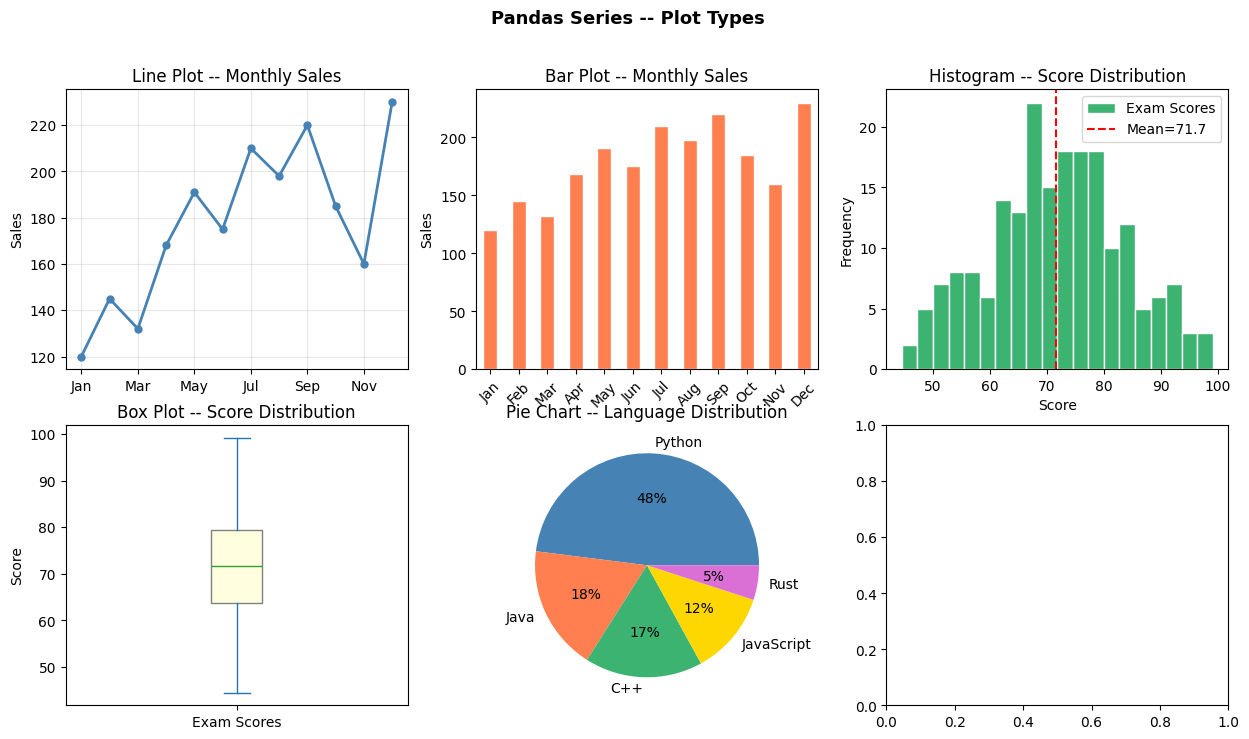

In [31]:
# --------------------------------------------------
# SERIES PLOTS
# Series.plot() wraps matplotlib
# --------------------------------------------------

np.random.seed(7)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Pandas Series -- Plot Types", fontsize=13, fontweight='bold')

# Data
monthly_sales = pd.Series(
    [120, 145, 132, 168, 191, 175, 210, 198, 220, 185, 160, 230],
    index=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
    name="Monthly Sales (thousands)"
)
scores_dist = pd.Series(np.random.normal(72, 12, 200).clip(0, 100), name="Exam Scores")
category_data = pd.Series(
    np.random.choice(["Python","Java","C++","JavaScript","Rust"], 100,
                     p=[0.45, 0.25, 0.15, 0.10, 0.05]),
    name="Language"
)

# 1. Line plot
monthly_sales.plot(ax=axes[0,0], kind='line', marker='o', color='steelblue',
                   linewidth=2, markersize=5)
axes[0,0].set_title("Line Plot -- Monthly Sales")
axes[0,0].set_ylabel("Sales")
axes[0,0].grid(True, alpha=0.3)

# 2. Bar plot
monthly_sales.plot(ax=axes[0,1], kind='bar', color='coral', edgecolor='white')
axes[0,1].set_title("Bar Plot -- Monthly Sales")
axes[0,1].set_ylabel("Sales")
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Histogram
scores_dist.plot(ax=axes[0,2], kind='hist', bins=20, color='mediumseagreen',
                 edgecolor='white')
axes[0,2].axvline(scores_dist.mean(), color='red', linestyle='--',
                   label=f'Mean={scores_dist.mean():.1f}')
axes[0,2].set_title("Histogram -- Score Distribution")
axes[0,2].set_xlabel("Score")
axes[0,2].legend()

# 4. Box plot
scores_dist.plot(ax=axes[1,0], kind='box', patch_artist=True,
                 boxprops=dict(facecolor='lightyellow', color='gray'))
axes[1,0].set_title("Box Plot -- Score Distribution")
axes[1,0].set_ylabel("Score")

# 5. Pie chart (value_counts)
vc = category_data.value_counts()
vc.plot(ax=axes[1,1], kind='pie', autopct='%1.0f%%',
        colors=['steelblue','coral','mediumseagreen','gold','orchid'])
axes[1,1].set_title("Pie Chart -- Language Distribution")
axes[1,1].set_ylabel("")

# 6. KDE (Kernel Density Estimate)
scores_dist.plot(ax=axes[1,2], kind='kde', color='purple', linewidth=2)
axes[1,2].set_title("KDE -- Score Density")
axes[1,2].set_xlabel("Score")
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# SECTION 11 -- String Methods (.str accessor)

String operations on Series -- vectorized, no loop needed.

In [32]:
names = pd.Series(
    ["  Virat Kohli  ", "rohit sharma", "MS DHONI", "jasprit bumrah", "hardik pandya"],
    name="players"
)
print("Original:", names.tolist())
print()

print("str.strip():    ", names.str.strip().tolist())
print("str.upper():    ", names.str.strip().str.upper().tolist())
print("str.lower():    ", names.str.strip().str.lower().tolist())
print("str.title():    ", names.str.strip().str.title().tolist())
print("str.len():      ", names.str.strip().str.len().tolist())
print("str.split():    ", names.str.strip().str.split().tolist())
print("str.contains('kohli', case=False):", names.str.contains('kohli', case=False).tolist())
print("str.startswith('  '):              ", names.str.startswith('  ').tolist())
print("str.replace(' ', '_'):             ", names.str.strip().str.replace(' ', '_').tolist())

# Extract first name
first_names = names.str.strip().str.title().str.split().str[0]
print(f"\nFirst names: {first_names.tolist()}")

Original: ['  Virat Kohli  ', 'rohit sharma', 'MS DHONI', 'jasprit bumrah', 'hardik pandya']

str.strip():     ['Virat Kohli', 'rohit sharma', 'MS DHONI', 'jasprit bumrah', 'hardik pandya']
str.upper():     ['VIRAT KOHLI', 'ROHIT SHARMA', 'MS DHONI', 'JASPRIT BUMRAH', 'HARDIK PANDYA']
str.lower():     ['virat kohli', 'rohit sharma', 'ms dhoni', 'jasprit bumrah', 'hardik pandya']
str.title():     ['Virat Kohli', 'Rohit Sharma', 'Ms Dhoni', 'Jasprit Bumrah', 'Hardik Pandya']
str.len():       [11, 12, 8, 14, 13]
str.split():     [['Virat', 'Kohli'], ['rohit', 'sharma'], ['MS', 'DHONI'], ['jasprit', 'bumrah'], ['hardik', 'pandya']]
str.contains('kohli', case=False): [True, False, False, False, False]
str.startswith('  '):               [True, False, False, False, False]
str.replace(' ', '_'):              ['Virat_Kohli', 'rohit_sharma', 'MS_DHONI', 'jasprit_bumrah', 'hardik_pandya']

First names: ['Virat', 'Rohit', 'Ms', 'Jasprit', 'Hardik']


---
# SECTION 12 -- CAPSTONE: Cricket Player Score Analysis

Ek real-world analysis -- Virat Kohli ke T20 match scores ko Series mein analyse karo.
Saare concepts ek saath use honge.

In [33]:
# --------------------------------------------------
# DATASET -- Virat Kohli T20 Scores (simulated)
# --------------------------------------------------

np.random.seed(18)  # 18 = Kohli's jersey number

# Realistic T20 score distribution
# Many low scores, few big ones -- realistic distribution
n_innings = 50
scores_sim = np.concatenate([
    np.array([0, 0, 0, 0]),           # ducks (realistic)
    np.random.randint(1, 20, 10),      # low scores
    np.random.randint(20, 50, 15),     # moderate
    np.random.randint(50, 80, 12),     # good innings
    np.random.randint(80, 122, 5),     # great innings
    np.array([82, 73, 90, 55])         # specific memorable scores
])
np.random.shuffle(scores_sim)

opponents = [
    "Australia", "England", "Pakistan", "South Africa", "New Zealand",
    "West Indies", "Sri Lanka", "Bangladesh", "Afghanistan", "Ireland"
] * 5
np.random.shuffle(opponents)

match_labels = [f"T20_{i+1:03d}" for i in range(n_innings)]

kohli_scores = pd.Series(
    scores_sim[:n_innings],
    index=match_labels,
    name="Virat_Kohli_T20_Runs"
)

print("=" * 55)
print("VIRAT KOHLI -- T20 SCORE ANALYSIS")
print("=" * 55)
print(f"Total innings analysed: {kohli_scores.size}")
print(f"dtype: {kohli_scores.dtype}")
print(f"\nFirst 10 innings:")
print(kohli_scores.head(10))

VIRAT KOHLI -- T20 SCORE ANALYSIS
Total innings analysed: 50
dtype: int64

First 10 innings:
T20_001    55
T20_002    30
T20_003    18
T20_004     9
T20_005    83
T20_006    31
T20_007     0
T20_008    56
T20_009    11
T20_010    31
Name: Virat_Kohli_T20_Runs, dtype: int64


In [34]:
# --------------------------------------------------
# BASIC STATISTICS
# --------------------------------------------------

print("=" * 55)
print("CAREER STATISTICS")
print("=" * 55)
print(f"  Total runs:      {kohli_scores.sum()}")
print(f"  Innings:         {kohli_scores.count()}")
print(f"  Average:         {kohli_scores.mean():.2f}")
print(f"  Median score:    {kohli_scores.median():.2f}")
print(f"  Highest score:   {kohli_scores.max()} ({kohli_scores.idxmax()})")
print(f"  Lowest score:    {kohli_scores.min()} ({kohli_scores.idxmin()})")
print(f"  Std deviation:   {kohli_scores.std():.2f}")
print(f"  25th percentile: {kohli_scores.quantile(0.25):.2f}")
print(f"  75th percentile: {kohli_scores.quantile(0.75):.2f}")

print(f"\n  describe():")
print(kohli_scores.describe().round(2))

CAREER STATISTICS
  Total runs:      2107
  Innings:         50
  Average:         42.14
  Median score:    37.50
  Highest score:   108 (T20_042)
  Lowest score:    0 (T20_007)
  Std deviation:   30.13
  25th percentile: 18.25
  75th percentile: 63.75

  describe():
count     50.00
mean      42.14
std       30.13
min        0.00
25%       18.25
50%       37.50
75%       63.75
max      108.00
Name: Virat_Kohli_T20_Runs, dtype: float64


In [35]:
# --------------------------------------------------
# PERFORMANCE CATEGORIES -- boolean indexing
# --------------------------------------------------

ducks       = kohli_scores[kohli_scores == 0]
low         = kohli_scores[(kohli_scores > 0) & (kohli_scores < 20)]
moderate    = kohli_scores[(kohli_scores >= 20) & (kohli_scores < 50)]
good        = kohli_scores[(kohli_scores >= 50) & (kohli_scores < 80)]
fifties     = kohli_scores[(kohli_scores >= 50) & (kohli_scores < 100)]
centuries   = kohli_scores[kohli_scores >= 100]

print("=" * 55)
print("PERFORMANCE BREAKDOWN")
print("=" * 55)
total = len(kohli_scores)

categories = [
    ("Ducks (0)",          ducks),
    ("Low (1-19)",         low),
    ("Moderate (20-49)",   moderate),
    ("Good (50-79)",       good),
    ("Centuries (100+)",   centuries),
]

for label, subset in categories:
    count = len(subset)
    pct   = count / total * 100
    avg   = subset.mean() if count > 0 else 0
    bar   = '#' * count
    print(f"  {label:<22}: {count:>3} ({pct:>5.1f}%)  avg={avg:>5.1f}  {bar}")

print(f"\n  Fifties (50-99):  {len(fifties)} innings")
print(f"  Strike rate proxy: {kohli_scores.mean() / 20 * 100:.1f}  (runs per 20 balls, simulated)")

PERFORMANCE BREAKDOWN
  Ducks (0)             :   4 (  8.0%)  avg=  0.0  ####
  Low (1-19)            :  10 ( 20.0%)  avg= 10.8  ##########
  Moderate (20-49)      :  15 ( 30.0%)  avg= 31.2  ###############
  Good (50-79)          :  14 ( 28.0%)  avg= 64.1  ##############
  Centuries (100+)      :   1 (  2.0%)  avg=108.0  #

  Fifties (50-99):  20 innings
  Strike rate proxy: 210.7  (runs per 20 balls, simulated)


In [36]:
# --------------------------------------------------
# FORM ANALYSIS -- cumulative and running stats
# --------------------------------------------------

print("FORM ANALYSIS")
print("=" * 55)

running_avg = kohli_scores.expanding().mean()
rolling_5   = kohli_scores.rolling(window=5).mean()

print(f"Running average (last 5 innings): {running_avg.tail(5).round(2).tolist()}")
print(f"Rolling mean (window=5) last 5:   {rolling_5.tail(5).round(2).tolist()}")

# Best and worst 5-match stretch
rolling_5_clean = rolling_5.dropna()
best_stretch_idx  = rolling_5_clean.idxmax()
worst_stretch_idx = rolling_5_clean.idxmin()
print(f"\nBest 5-match avg:  {rolling_5_clean.max():.2f} (ending at {best_stretch_idx})")
print(f"Worst 5-match avg: {rolling_5_clean.min():.2f} (ending at {worst_stretch_idx})")

# Consistency: innings where scored 20+
consistent = kohli_scores >= 20
print(f"\nConsistency (scored 20+): {consistent.sum()}/{len(kohli_scores)} = {consistent.mean()*100:.1f}%")

# Score buckets using value_counts
buckets = pd.cut(kohli_scores, bins=[0, 10, 30, 50, 80, 130],
                  labels=["0-10", "11-30", "31-50", "51-80", "81+"],
                  include_lowest=True)
print(f"\nScore bucket distribution:")
print(pd.Series(buckets).value_counts().sort_index())

FORM ANALYSIS
Running average (last 5 innings): [41.2, 42.34, 41.52, 41.55, 42.14]
Rolling mean (window=5) last 5:   [55.0, 52.4, 48.2, 44.0, 54.0]

Best 5-match avg:  63.40 (ending at T20_040)
Worst 5-match avg: 12.00 (ending at T20_029)

Consistency (scored 20+): 36/50 = 72.0%

Score bucket distribution:
Virat_Kohli_T20_Runs
0-10      9
11-30    13
31-50     8
51-80    13
81+       7
Name: count, dtype: int64


In [37]:
# --------------------------------------------------
# value_counts DEMO on scores
# --------------------------------------------------

print("Most frequent scores (value_counts):")
print(kohli_scores.value_counts().head(10))

print("\nScore distribution (bins):")
print(kohli_scores.value_counts(bins=6, sort=False))

Most frequent scores (value_counts):
Virat_Kohli_T20_Runs
0     4
30    2
31    2
83    2
24    2
18    2
3     2
63    2
6     2
41    2
Name: count, dtype: int64

Score distribution (bins):
(-0.109, 18.0]    13
(18.0, 36.0]      12
(36.0, 54.0]       5
(54.0, 72.0]      10
(72.0, 90.0]       7
(90.0, 108.0]      3
Name: count, dtype: int64


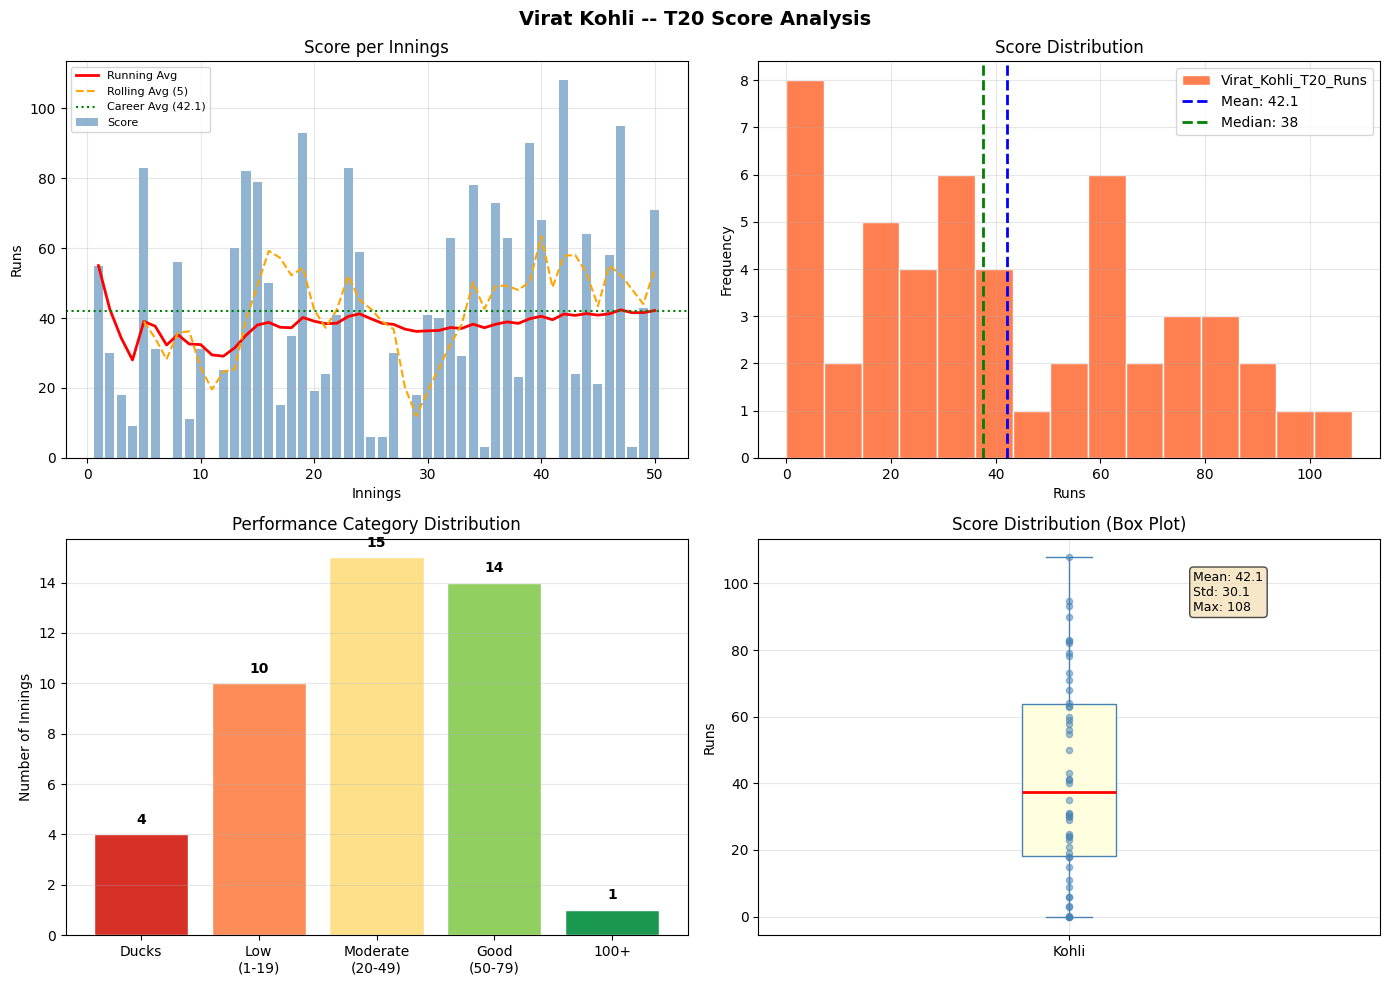

Analysis complete.


In [38]:
# --------------------------------------------------
# FULL ANALYSIS PLOT
# --------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Virat Kohli -- T20 Score Analysis", fontsize=14, fontweight='bold')

# Plot 1: Score per innings + running average
ax1 = axes[0, 0]
innings_nums = range(1, len(kohli_scores) + 1)
ax1.bar(innings_nums, kohli_scores.values, color='steelblue', alpha=0.6, label='Score')
ax1.plot(innings_nums, running_avg.values, color='red', linewidth=2, label='Running Avg')
ax1.plot(innings_nums, rolling_5.values, color='orange', linewidth=1.5,
         linestyle='--', label='Rolling Avg (5)')
ax1.axhline(kohli_scores.mean(), color='green', linestyle=':', linewidth=1.5,
             label=f'Career Avg ({kohli_scores.mean():.1f})')
ax1.set_title("Score per Innings")
ax1.set_xlabel("Innings")
ax1.set_ylabel("Runs")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Score distribution histogram
ax2 = axes[0, 1]
kohli_scores.plot(kind='hist', bins=15, ax=ax2, color='coral', edgecolor='white')
ax2.axvline(kohli_scores.mean(), color='blue', linestyle='--', linewidth=2,
             label=f'Mean: {kohli_scores.mean():.1f}')
ax2.axvline(kohli_scores.median(), color='green', linestyle='--', linewidth=2,
              label=f'Median: {kohli_scores.median():.0f}')
ax2.set_title("Score Distribution")
ax2.set_xlabel("Runs")
ax2.set_ylabel("Frequency")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Performance category bar
ax3 = axes[1, 0]
cat_labels = ["Ducks", "Low\n(1-19)", "Moderate\n(20-49)", "Good\n(50-79)", "100+"]
cat_counts = [len(ducks), len(low), len(moderate), len(good), len(centuries)]
colors = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']
bars = ax3.bar(cat_labels, cat_counts, color=colors, edgecolor='white')
for bar, count in zip(bars, cat_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title("Performance Category Distribution")
ax3.set_ylabel("Number of Innings")
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Box plot with swarm
ax4 = axes[1, 1]
bp = ax4.boxplot(kohli_scores.values, patch_artist=True, vert=True,
                  boxprops=dict(facecolor='lightyellow', color='steelblue'),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(color='steelblue'),
                  capprops=dict(color='steelblue'))
ax4.scatter([1]*len(kohli_scores),
             kohli_scores.values + np.random.uniform(-0.15, 0.15, len(kohli_scores)),
             alpha=0.5, color='steelblue', s=20, zorder=3)
ax4.set_title("Score Distribution (Box Plot)")
ax4.set_ylabel("Runs")
ax4.set_xticklabels(["Kohli"])
stats_text = f"Mean: {kohli_scores.mean():.1f}\nStd: {kohli_scores.std():.1f}\nMax: {kohli_scores.max()}"
ax4.text(1.2, kohli_scores.max() * 0.85, stats_text, fontsize=9,
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Analysis complete.")

In [39]:
# --------------------------------------------------
# FINAL REPORT -- using all Series concepts
# --------------------------------------------------

print("=" * 55)
print("VIRAT KOHLI T20 -- FINAL REPORT")
print("=" * 55)

# Attributes used
print(f"  Series name:        {kohli_scores.name}")
print(f"  Total innings:      {kohli_scores.size}")
print(f"  dtype:              {kohli_scores.dtype}")
print(f"  is_unique:          {kohli_scores.is_unique}")

# Math methods
print(f"\n  Total runs:         {kohli_scores.sum()}")
print(f"  Batting average:    {kohli_scores.mean():.2f}")
print(f"  Median:             {kohli_scores.median():.2f}")
print(f"  Highest:            {kohli_scores.max()} at {kohli_scores.idxmax()}")
print(f"  Std deviation:      {kohli_scores.std():.2f}")

# Boolean indexing results
print(f"\n  Ducks:              {(kohli_scores == 0).sum()}")
print(f"  Fifties (50-99):    {((kohli_scores >= 50) & (kohli_scores < 100)).sum()}")
print(f"  Centuries (100+):   {(kohli_scores >= 100).sum()}")
print(f"  Below avg innings:  {(kohli_scores < kohli_scores.mean()).sum()}")
print(f"  Above avg innings:  {(kohli_scores >= kohli_scores.mean()).sum()}")

# Sorting insights
top5 = kohli_scores.nlargest(5)
print(f"\n  Top 5 innings:")
for match, runs in top5.items():
    print(f"    {match}: {runs} runs")

# describe
print(f"\n  Full statistics:")
print(kohli_scores.describe().round(2).to_string())

# Consistency metric
above_30 = (kohli_scores >= 30).mean() * 100
print(f"\n  Innings with 30+ runs: {above_30:.1f}%")
print(f"  Consistency rating:    {'Excellent' if above_30 > 50 else 'Good' if above_30 > 35 else 'Needs improvement'}")

VIRAT KOHLI T20 -- FINAL REPORT
  Series name:        Virat_Kohli_T20_Runs
  Total innings:      50
  dtype:              int64
  is_unique:          False

  Total runs:         2107
  Batting average:    42.14
  Median:             37.50
  Highest:            108 at T20_042
  Std deviation:      30.13

  Ducks:              4
  Fifties (50-99):    20
  Centuries (100+):   1
  Below avg innings:  28
  Above avg innings:  22

  Top 5 innings:
    T20_042: 108 runs
    T20_047: 95 runs
    T20_019: 93 runs
    T20_039: 90 runs
    T20_005: 83 runs

  Full statistics:
count     50.00
mean      42.14
std       30.13
min        0.00
25%       18.25
50%       37.50
75%       63.75
max      108.00

  Innings with 30+ runs: 60.0%
  Consistency rating:    Excellent


---
# Day 11 Summary -- Pandas Series

| Concept | Key Methods | Use Case |
|---------|-------------|----------|
| Creation | pd.Series(list/dict/array/scalar) | Any 1D data |
| Attributes | .name, .dtype, .size, .shape, .index, .values, .is_unique, .hasnans | Inspect Series |
| Viewing | head, tail, sample, value_counts | Quick exploration |
| Sorting | sort_values, sort_index, nlargest, nsmallest | Order data |
| Stats | mean, median, mode, std, describe, quantile, skew | EDA |
| Cumulative | cumsum, cummax, cummin, rolling, expanding | Time series |
| Indexing | .loc (label), .iloc (position) | Select data |
| Boolean idx | s[s > 5], s[(s>2) & (s<8)] | Filter rows |
| Arithmetic | +, -, *, / with index alignment | Math on data |
| astype | s.astype(int), pd.to_numeric | Type conversion |
| between/clip | between(lo, hi), clip(lo, hi) | Range operations |
| NaN handling | isnull, dropna, fillna, ffill, bfill, interpolate | Missing data |
| Membership | isin([...]) | Filter by list |
| Apply/Map | apply(func), map(dict) | Custom transforms |
| Strings | .str.upper, .str.contains, .str.split | Text data |
| Plots | .plot(kind='line/bar/hist/box/kde') | Visualization |

